In [1]:
# ----------------------------
# 1: Word2Vec - CBOW Implementation (Conceptual)
# ----------------------------
import numpy as np
from collections import defaultdict

# Sample corpus
corpus = [
    "the cat sits on the mat",
    "the dog sits on the log",
    "cats and dogs are animals",
    "machine learning is great"
]

# Tokenize
tokens = [sentence.split() for sentence in corpus]
flat_tokens = [word for sentence in tokens for word in sentence]

# Build vocabulary
vocab = sorted(set(flat_tokens))
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}

print("Vocabulary:", vocab)
print(f"Vocabulary size: {len(vocab)}")
print("\nWord to Index mapping (sample):")
for word in list(vocab)[:5]:
    print(f"  {word}: {word_to_idx[word]}")

# CBOW: Generate training data (context -> target)
def generate_cbow_data(tokens, window_size=2):
    """Generate CBOW training pairs: (context_words, target_word)"""
    data = []
    for sentence in tokens:
        for i, target in enumerate(sentence):
            # Get context words within window
            context = []
            for j in range(max(0, i - window_size), min(len(sentence), i + window_size + 1)):
                if j != i:
                    context.append(sentence[j])
            if context:
                data.append((context, target))
    return data

cbow_data = generate_cbow_data(tokens, window_size=2)

print(f"\nCBOW Training pairs (first 5):")
for context, target in cbow_data[:5]:
    print(f"  Context: {context} -> Target: {target}")

# Output:
# Vocabulary: ['and', 'animals', 'are', 'cat', 'cats', 'dog', 'dogs', 'great', 'is', 'learning', 'log', 'machine', 'mat', 'on', 'sits', 'the']
# Vocabulary size: 16

# Word to Index mapping (sample):
#   and: 0
#   animals: 1
#   are: 2
#   cat: 3
#   cats: 4

# CBOW Training pairs (first 5):
#   Context: ['cat', 'sits'] -> Target: the
#   Context: ['the', 'sits', 'on'] -> Target: cat
#   Context: ['the', 'cat', 'on', 'the'] -> Target: sits
#   Context: ['cat', 'sits', 'the', 'mat'] -> Target: on
#   Context: ['sits', 'on', 'mat'] -> Target: the


Vocabulary: ['and', 'animals', 'are', 'cat', 'cats', 'dog', 'dogs', 'great', 'is', 'learning', 'log', 'machine', 'mat', 'on', 'sits', 'the']
Vocabulary size: 16

Word to Index mapping (sample):
  and: 0
  animals: 1
  are: 2
  cat: 3
  cats: 4

CBOW Training pairs (first 5):
  Context: ['cat', 'sits'] -> Target: the
  Context: ['the', 'sits', 'on'] -> Target: cat
  Context: ['the', 'cat', 'on', 'the'] -> Target: sits
  Context: ['cat', 'sits', 'the', 'mat'] -> Target: on
  Context: ['sits', 'on', 'mat'] -> Target: the


In [2]:
# ----------------------------
# 2: Word2Vec - Skip-gram Implementation (Conceptual)
# ----------------------------

# Skip-gram: Generate training data (target -> context)
def generate_skipgram_data(tokens, window_size=2):
    """Generate Skip-gram training pairs: (target_word, context_word)"""
    data = []
    for sentence in tokens:
        for i, target in enumerate(sentence):
            # Get context words within window
            for j in range(max(0, i - window_size), min(len(sentence), i + window_size + 1)):
                if j != i:
                    context = sentence[j]
                    data.append((target, context))
    return data

skipgram_data = generate_skipgram_data(tokens, window_size=2)

print("Skip-gram Training pairs (first 10):")
for target, context in skipgram_data[:10]:
    print(f"  Target: {target} -> Context: {context}")

print(f"\nTotal CBOW pairs: {len(cbow_data)}")
print(f"Total Skip-gram pairs: {len(skipgram_data)}")
print("\nKey Difference:")
print("  CBOW: Multiple context words -> 1 target word")
print("  Skip-gram: 1 target word -> multiple context words (separate pairs)")

# Output:
# Skip-gram Training pairs (first 10):
#   Target: the -> Context: cat
#   Target: the -> Context: sits
#   Target: cat -> Context: the
#   Target: cat -> Context: sits
#   Target: cat -> Context: on
#   Target: sits -> Context: the
#   Target: sits -> Context: cat
#   Target: sits -> Context: on
#   Target: sits -> Context: the
#   Target: on -> Context: cat

# Total CBOW pairs: 21
# Total Skip-gram pairs: 60

# Key Difference:
#   CBOW: Multiple context words -> 1 target word
#   Skip-gram: 1 target word -> multiple context words (separate pairs)


Skip-gram Training pairs (first 10):
  Target: the -> Context: cat
  Target: the -> Context: sits
  Target: cat -> Context: the
  Target: cat -> Context: sits
  Target: cat -> Context: on
  Target: sits -> Context: the
  Target: sits -> Context: cat
  Target: sits -> Context: on
  Target: sits -> Context: the
  Target: on -> Context: cat

Total CBOW pairs: 21
Total Skip-gram pairs: 60

Key Difference:
  CBOW: Multiple context words -> 1 target word
  Skip-gram: 1 target word -> multiple context words (separate pairs)


In [3]:
# ----------------------------
# 3: Word2Vec with Gensim - CBOW
# ----------------------------
# pip install gensim

from gensim.models import Word2Vec

# Train CBOW model
print("Training CBOW model...")
cbow_model = Word2Vec(
    sentences=tokens,
    vector_size=50,        # Embedding dimension
    window=2,              # Context window size
    min_count=1,           # Minimum word frequency
    sg=0,                  # 0 = CBOW, 1 = Skip-gram
    epochs=100,
    seed=42
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(cbow_model.wv)}")
print(f"Vector dimension: {cbow_model.wv.vector_size}")

# Get word vectors
cat_vector = cbow_model.wv['cat']
print(f"\nVector for 'cat' (first 10 dimensions):")
print(cat_vector[:10])

# Find similar words
print("\nMost similar words to 'cat':")
similar_words = cbow_model.wv.most_similar('cat', topn=3)
for word, similarity in similar_words:
    print(f"  {word}: {similarity:.4f}")

# Vector arithmetic
print("\nVector arithmetic example:")
print("'sits' most similar words:")
result = cbow_model.wv.most_similar('sits', topn=3)
for word, sim in result:
    print(f"  {word}: {sim:.4f}")

# Output:
# Training CBOW model...
# CBOW Model trained!
# Vocabulary size: 16
# Vector dimension: 50

# Vector for 'cat' (first 10 dimensions):
# [ 0.01851981 -0.01411542 -0.0165438   0.01740018  0.00226768 -0.00249407
#   0.00945551 -0.00466436 -0.01490149  0.00921375]

# Most similar words to 'cat':
#   on: 0.1654
#   dog: 0.0943
#   animals: 0.0473

# Vector arithmetic example:
# 'sits' most similar words:
#   great: 0.2235
#   animals: 0.1959
#   log: 0.1634


Training CBOW model...
CBOW Model trained!
Vocabulary size: 16
Vector dimension: 50

Vector for 'cat' (first 10 dimensions):
[ 0.01851981 -0.01411542 -0.0165438   0.01740018  0.00226768 -0.00249407
  0.00945551 -0.00466436 -0.01490149  0.00921375]

Most similar words to 'cat':
  on: 0.1654
  dog: 0.0943
  animals: 0.0473

Vector arithmetic example:
'sits' most similar words:
  great: 0.2235
  animals: 0.1959
  log: 0.1634


In [4]:
# ----------------------------
# 4: Word2Vec with Gensim - Skip-gram
# ----------------------------

# Train Skip-gram model
print("Training Skip-gram model...")
skipgram_model = Word2Vec(
    sentences=tokens,
    vector_size=50,
    window=2,
    min_count=1,
    sg=1,                  # 1 = Skip-gram
    epochs=100,
    seed=42
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(skipgram_model.wv)}")

# Compare CBOW vs Skip-gram vectors
cat_cbow = cbow_model.wv['cat']
cat_skipgram = skipgram_model.wv['cat']

print(f"\nCBOW 'cat' vector (first 5): {cat_cbow[:5]}")
print(f"Skip-gram 'cat' vector (first 5): {cat_skipgram[:5]}")

# Compare similarities
from sklearn.metrics.pairwise import cosine_similarity

print("\nWord similarities - CBOW:")
for word in ['dog', 'sits', 'learning']:
    if word in cbow_model.wv:
        sim = cosine_similarity(
            cat_cbow.reshape(1, -1),
            cbow_model.wv[word].reshape(1, -1)
        )[0][0]
        print(f"  cat <-> {word}: {sim:.4f}")

print("\nWord similarities - Skip-gram:")
for word in ['dog', 'sits', 'learning']:
    if word in skipgram_model.wv:
        sim = cosine_similarity(
            cat_skipgram.reshape(1, -1),
            skipgram_model.wv[word].reshape(1, -1)
        )[0][0]
        print(f"  cat <-> {word}: {sim:.4f}")

# Output:
# Training Skip-gram model...
# Skip-gram Model trained!
# Vocabulary size: 16

# CBOW 'cat' vector (first 5): [ 0.01851981 -0.01411542 -0.0165438   0.01740018  0.00226768]
# Skip-gram 'cat' vector (first 5): [ 0.01852669 -0.0141119  -0.01653065  0.01739628  0.00228855]

# Word similarities - CBOW:
#   cat <-> dog: 0.0943
#   cat <-> sits: -0.0561
#   cat <-> learning: 0.0286

# Word similarities - Skip-gram:
#   cat <-> dog: 0.0937
#   cat <-> sits: -0.0558
#   cat <-> learning: 0.0284

Training Skip-gram model...
Skip-gram Model trained!
Vocabulary size: 16

CBOW 'cat' vector (first 5): [ 0.01851981 -0.01411542 -0.0165438   0.01740018  0.00226768]
Skip-gram 'cat' vector (first 5): [ 0.01852669 -0.0141119  -0.01653065  0.01739628  0.00228855]

Word similarities - CBOW:
  cat <-> dog: 0.0943
  cat <-> sits: -0.0561
  cat <-> learning: 0.0286

Word similarities - Skip-gram:
  cat <-> dog: 0.0937
  cat <-> sits: -0.0558
  cat <-> learning: 0.0284


In [5]:
# ----------------------------
# 5: Negative Sampling Demonstration
# ----------------------------

# Negative sampling: sample words that are NOT in the context
def generate_negative_samples(target_word, context_word, vocab, n_negative=5):
    """Generate negative samples for Skip-gram with negative sampling"""
    # Positive pair
    positive = (target_word, context_word, 1)  # Label: 1
    
    # Negative samples
    negatives = []
    vocab_list = list(vocab)
    
    # Sample words that are NOT the context word
    import random
    random.seed(42)
    for _ in range(n_negative):
        neg_word = random.choice(vocab_list)
        while neg_word == context_word:
            neg_word = random.choice(vocab_list)
        negatives.append((target_word, neg_word, 0))  # Label: 0
    
    return positive, negatives

# Example
target = "cat"
context = "sits"

positive, negatives = generate_negative_samples(target, context, vocab, n_negative=5)

print(f"Target word: {target}")
print(f"\nPositive pair (actual context):")
print(f"  ({positive[0]}, {positive[1]}) -> Label: {positive[2]}")

print(f"\nNegative samples (random words, not in context):")
for neg in negatives:
    print(f"  ({neg[0]}, {neg[1]}) -> Label: {neg[2]}")

print("\nObjective:")
print("  Maximize: P(context | target) for positive pair")
print("  Minimize: P(negative_word | target) for negative samples")
print("\nThis is much faster than computing softmax over entire vocabulary!")
# Output:
# Target word: cat

# Positive pair (actual context):
#   (cat, sits) -> Label: 1

# Negative samples (random words, not in context):
#   (cat, cat) -> Label: 0
#   (cat, and) -> Label: 0
#   (cat, is) -> Label: 0
#   (cat, great) -> Label: 0
#   (cat, great) -> Label: 0

# Objective:
#   Maximize: P(context | target) for positive pair
#   Minimize: P(negative_word | target) for negative samples

# This is much faster than computing softmax over entire vocabulary!


Target word: cat

Positive pair (actual context):
  (cat, sits) -> Label: 1

Negative samples (random words, not in context):
  (cat, cat) -> Label: 0
  (cat, and) -> Label: 0
  (cat, is) -> Label: 0
  (cat, great) -> Label: 0
  (cat, great) -> Label: 0

Objective:
  Maximize: P(context | target) for positive pair
  Minimize: P(negative_word | target) for negative samples

This is much faster than computing softmax over entire vocabulary!


In [6]:
# ----------------------------
# 6: Training with Larger Corpus
# ----------------------------

# Larger corpus for better embeddings
large_corpus = [
    "the cat sits on the mat",
    "the dog sits on the log",
    "cats and dogs are animals",
    "the cat and dog play together",
    "machine learning is fascinating",
    "deep learning uses neural networks",
    "natural language processing analyzes text",
    "word embeddings capture semantic meaning",
    "the quick brown fox jumps over the lazy dog",
    "cats are independent animals",
    "dogs are loyal companions",
    "neural networks learn from data"
]

large_tokens = [sentence.split() for sentence in large_corpus]

# Train both models
print("Training on larger corpus...")
cbow_large = Word2Vec(large_tokens, vector_size=100, window=3, 
                      min_count=1, sg=0, epochs=100, seed=42)
skipgram_large = Word2Vec(large_tokens, vector_size=100, window=3,
                          min_count=1, sg=1, epochs=100, seed=42)

print(f"Vocabulary size: {len(cbow_large.wv)}")

# Test semantic relationships
print("\nSemantic Similarity Tests:")
test_pairs = [
    ('cat', 'dog'),
    ('cat', 'animals'),
    ('learning', 'neural'),
    ('machine', 'deep')
]

print("\nCBOW similarities:")
for w1, w2 in test_pairs:
    if w1 in cbow_large.wv and w2 in cbow_large.wv:
        sim = cbow_large.wv.similarity(w1, w2)
        print(f"  {w1} <-> {w2}: {sim:.4f}")

print("\nSkip-gram similarities:")
for w1, w2 in test_pairs:
    if w1 in skipgram_large.wv and w2 in skipgram_large.wv:
        sim = skipgram_large.wv.similarity(w1, w2)
        print(f"  {w1} <-> {w2}: {sim:.4f}")
# Output:
# Training on larger corpus...
# Vocabulary size: 44

# Semantic Similarity Tests:

# CBOW similarities:
#   cat <-> dog: -0.0708
#   cat <-> animals: -0.0072
#   learning <-> neural: 0.0585
#   machine <-> deep: 0.1726

# Skip-gram similarities:
#   cat <-> dog: -0.0461
#   cat <-> animals: -0.0015
#   learning <-> neural: 0.0600
#   machine <-> deep: 0.1882


Training on larger corpus...
Vocabulary size: 44

Semantic Similarity Tests:

CBOW similarities:
  cat <-> dog: -0.0708
  cat <-> animals: -0.0072
  learning <-> neural: 0.0585
  machine <-> deep: 0.1726

Skip-gram similarities:
  cat <-> dog: -0.0461
  cat <-> animals: -0.0015
  learning <-> neural: 0.0600
  machine <-> deep: 0.1882


In [7]:
# ----------------------------
# 7: GloVe - Building Co-occurrence Matrix
# ----------------------------

from collections import defaultdict
from scipy.sparse import lil_matrix

def build_cooccurrence_matrix(tokens, window_size=2):
    """Build word-word co-occurrence matrix"""
    # Get vocabulary
    vocab = sorted(set(word for sentence in tokens for word in sentence))
    word_to_idx = {w: i for i, w in enumerate(vocab)}
    
    # Initialize co-occurrence matrix
    vocab_size = len(vocab)
    cooccur = defaultdict(float)
    
    # Count co-occurrences
    for sentence in tokens:
        for i, target in enumerate(sentence):
            target_idx = word_to_idx[target]
            
            # Look at words in window
            for j in range(max(0, i - window_size), 
                          min(len(sentence), i + window_size + 1)):
                if i != j:
                    context = sentence[j]
                    context_idx = word_to_idx[context]
                    
                    # Distance weighting: closer words have higher weight
                    distance = abs(i - j)
                    weight = 1.0 / distance
                    
                    cooccur[(target_idx, context_idx)] += weight
    
    # Convert to matrix
    matrix = lil_matrix((vocab_size, vocab_size))
    for (i, j), count in cooccur.items():
        matrix[i, j] = count
    
    return matrix.toarray(), vocab, word_to_idx

# Build matrix
cooccur_matrix, glove_vocab, glove_word_to_idx = build_cooccurrence_matrix(
    large_tokens, window_size=2
)

print("Co-occurrence Matrix:")
print(f"Shape: {cooccur_matrix.shape}")
print(f"Vocabulary size: {len(glove_vocab)}")

# Show sample co-occurrences
sample_words = ['cat', 'dog', 'the']
print("\nSample co-occurrence counts:")
print(f"{'Word':<10} ", end='')
for w in sample_words:
    if w in glove_word_to_idx:
        print(f"{w:<10}", end='')
print()

for w1 in sample_words:
    if w1 in glove_word_to_idx:
        idx1 = glove_word_to_idx[w1]
        print(f"{w1:<10} ", end='')
        for w2 in sample_words:
            if w2 in glove_word_to_idx:
                idx2 = glove_word_to_idx[w2]
                print(f"{cooccur_matrix[idx1, idx2]:<10.2f}", end='')
        print()

print("\nInterpretation:")
print("  Higher values = words appear together more frequently")

# Output:
# Co-occurrence Matrix:
# Shape: (44, 44)
# Vocabulary size: 44

# Sample co-occurrence counts:
# Word       cat       dog       the       
# cat        0.00      0.50      2.00      
# dog        0.50      0.00      1.50      
# the        2.00      1.50      0.00      

# Interpretation:
#   Higher values = words appear together more frequently


Co-occurrence Matrix:
Shape: (44, 44)
Vocabulary size: 44

Sample co-occurrence counts:
Word       cat       dog       the       
cat        0.00      0.50      2.00      
dog        0.50      0.00      1.50      
the        2.00      1.50      0.00      

Interpretation:
  Higher values = words appear together more frequently


In [8]:
# ----------------------------
# 8: GloVe - Using Pre-trained Vectors
# ----------------------------
# In practice, we use pre-trained GloVe vectors
# Here we'll simulate the GloVe objective

def glove_weighting_function(x, x_max=100, alpha=0.75):
    """GloVe weighting function f(X_ij)"""
    if x < x_max:
        return (x / x_max) ** alpha
    else:
        return 1.0

# Demonstrate weighting
x_values = [0, 1, 5, 10, 50, 100, 200]
print("GloVe Weighting Function:")
print(f"{'X_ij':<10} {'f(X_ij)':<10}")
print("-" * 20)
for x in x_values:
    weight = glove_weighting_function(x)
    print(f"{x:<10} {weight:<10.4f}")

print("\nInterpretation:")
print("  - Rare co-occurrences (x < x_max): downweighted")
print("  - Frequent co-occurrences (x >= x_max): full weight")
print("  - Prevents rare words from dominating the loss")

# Visualize the objective (conceptual)
print("\n" + "="*50)
print("GloVe Objective:")
print("="*50)
print("Minimize: Σ f(X_ij) * (w_i · w_j + b_i + b_j - log(X_ij))²")
print("\nWhere:")
print("  - w_i, w_j: word vectors")
print("  - b_i, b_j: bias terms")
print("  - X_ij: co-occurrence count")
print("  - f(X_ij): weighting function")
print("\nGoal: Make dot product approximate log of co-occurrence")
# Output:
# GloVe Weighting Function:
# X_ij       f(X_ij)   
# --------------------
# 0          0.0000    
# 1          0.0316    
# 5          0.1057    
# 10         0.1778    
# 50         0.5946    
# 100        1.0000    
# 200        1.0000    

# Interpretation:
#   - Rare co-occurrences (x < x_max): downweighted
#   - Frequent co-occurrences (x >= x_max): full weight
#   - Prevents rare words from dominating the loss

# ==================================================
# GloVe Objective:
# ==================================================
# Minimize: Σ f(X_ij) * (w_i · w_j + b_i + b_j - log(X_ij))²

# Where:
#   - w_i, w_j: word vectors
#   - b_i, b_j: bias terms
#   - X_ij: co-occurrence count
#   - f(X_ij): weighting function

# Goal: Make dot product approximate log of co-occurrence


GloVe Weighting Function:
X_ij       f(X_ij)   
--------------------
0          0.0000    
1          0.0316    
5          0.1057    
10         0.1778    
50         0.5946    
100        1.0000    
200        1.0000    

Interpretation:
  - Rare co-occurrences (x < x_max): downweighted
  - Frequent co-occurrences (x >= x_max): full weight
  - Prevents rare words from dominating the loss

GloVe Objective:
Minimize: Σ f(X_ij) * (w_i · w_j + b_i + b_j - log(X_ij))²

Where:
  - w_i, w_j: word vectors
  - b_i, b_j: bias terms
  - X_ij: co-occurrence count
  - f(X_ij): weighting function

Goal: Make dot product approximate log of co-occurrence


In [9]:
# ----------------------------
# 9: Vector Arithmetic with Word2Vec
# ----------------------------

# Classic example: king - man + woman ≈ queen
# We'll demonstrate with our trained models

def vector_arithmetic(model, positive, negative, topn=5):
    """Perform vector arithmetic: positive - negative"""
    try:
        result = model.wv.most_similar(
            positive=positive,
            negative=negative,
            topn=topn
        )
        return result
    except KeyError as e:
        return f"Word not in vocabulary: {e}"

print("Vector Arithmetic Examples:")
print("="*50)

# Example 1: cat - dog + learning
print("\n1. Analogy: cat is to dog as X is to learning")
print("   Formula: learning - dog + cat")
if all(w in skipgram_large.wv for w in ['learning', 'dog', 'cat']):
    result = vector_arithmetic(
        skipgram_large,
        positive=['learning', 'cat'],
        negative=['dog']
    )
    print("   Results:")
    for word, score in result:
        print(f"     {word}: {score:.4f}")

# Example 2: demonstrating semantic relationships
print("\n2. Analogy: cats is to cat as networks is to X")
print("   Formula: network - cats + cat")
if all(w in skipgram_large.wv for w in ['networks', 'cats', 'cat']):
    result = vector_arithmetic(
        skipgram_large,
        positive=['networks', 'cat'],
        negative=['cats']
    )
    print("   Results:")
    for word, score in result:
        print(f"     {word}: {score:.4f}")

print("\n" + "="*50)
print("Note: Better results require larger corpus and more training")
print("Pre-trained models (Word2Vec, GloVe) work much better!")
# Output:
# Vector Arithmetic Examples:
# ==================================================

# 1. Analogy: cat is to dog as X is to learning
#    Formula: learning - dog + cat
#    Results:
#      embeddings: 0.2404
#      lazy: 0.1585
#      cats: 0.1435
#      analyzes: 0.1245
#      sits: 0.1230

# 2. Analogy: cats is to cat as networks is to X
#    Formula: network - cats + cat
#    Results:
#      semantic: 0.2408
#      language: 0.2240
#      the: 0.2110
#      on: 0.1735
#      text: 0.1489

# ==================================================
# Note: Better results require larger corpus and more training
# Pre-trained models (Word2Vec, GloVe) work much better!


Vector Arithmetic Examples:

1. Analogy: cat is to dog as X is to learning
   Formula: learning - dog + cat
   Results:
     embeddings: 0.2404
     lazy: 0.1585
     cats: 0.1435
     analyzes: 0.1245
     sits: 0.1230

2. Analogy: cats is to cat as networks is to X
   Formula: network - cats + cat
   Results:
     semantic: 0.2408
     language: 0.2240
     the: 0.2110
     on: 0.1735
     text: 0.1489

Note: Better results require larger corpus and more training
Pre-trained models (Word2Vec, GloVe) work much better!


In [ ]:
# ----------------------------
# 10: FastText - Character N-grams
# ----------------------------

def generate_character_ngrams(word, n_min=3, n_max=6):
    """Generate character n-grams for a word"""
    # Add boundary markers
    word_with_boundaries = f"<{word}>"
    
    ngrams = []
    # Generate n-grams of different sizes
    for n in range(n_min, n_max + 1):
        for i in range(len(word_with_boundaries) - n + 1):
            ngram = word_with_boundaries[i:i+n]
            ngrams.append(ngram)
    
    # Also add the whole word
    ngrams.append(word_with_boundaries)
    
    return ngrams

# Example
test_words = ['playing', 'cats', 'learning']

print("Character N-grams Generation:")
print("="*50)
for word in test_words:
    ngrams = generate_character_ngrams(word, n_min=3, n_max=6)
    print(f"\nWord: {word}")
    print(f"  Total n-grams: {len(ngrams)}")
    print(f"  Sample n-grams: {ngrams[:10]}")

print("\n" + "="*50)
print("How FastText uses n-grams:")
print("  1. Generate n-grams for each word")
print("  2. Learn embeddings for each n-gram")
print("  3. Word vector = sum/average of its n-gram vectors")
print("  4. Can handle OOV words using n-gram composition")
# Output:
# Character N-grams Generation:
# ==================================================

# Word: playing
#   Total n-grams: 23
#   Sample n-grams: ['<pl', 'pla', 'lay', 'ayi', 'yin', 'ing', 'ng>', '<pla', 'play', 'layi']

# Word: cats
#   Total n-grams: 11
#   Sample n-grams: ['<ca', 'cat', 'ats', 'ts>', '<cat', 'cats', 'ats>', '<cats', 'cats>', '<cats>']

# Word: learning
#   Total n-grams: 27
#   Sample n-grams: ['<le', 'lea', 'ear', 'arn', 'rni', 'nin', 'ing', 'ng>', '<lea', 'lear']

# ==================================================
# How FastText uses n-grams:
#   1. Generate n-grams for each word
#   2. Learn embeddings for each n-gram
#   3. Word vector = sum/average of its n-gram vectors
#   4. Can handle OOV words using n-gram composition


Character N-grams Generation:

Word: playing
  Total n-grams: 23
  Sample n-grams: ['<pl', 'pla', 'lay', 'ayi', 'yin', 'ing', 'ng>', '<pla', 'play', 'layi']

Word: cats
  Total n-grams: 11
  Sample n-grams: ['<ca', 'cat', 'ats', 'ts>', '<cat', 'cats', 'ats>', '<cats', 'cats>', '<cats>']

Word: learning
  Total n-grams: 27
  Sample n-grams: ['<le', 'lea', 'ear', 'arn', 'rni', 'nin', 'ing', 'ng>', '<lea', 'lear']

How FastText uses n-grams:
  1. Generate n-grams for each word
  2. Learn embeddings for each n-gram
  3. Word vector = sum/average of its n-gram vectors
  4. Can handle OOV words using n-gram composition


In [11]:
# ----------------------------
# 11: FastText with Gensim
# ----------------------------
from gensim.models import FastText

# Train FastText model
print("Training FastText model...")
fasttext_model = FastText(
    sentences=large_tokens,
    vector_size=100,
    window=3,
    min_count=1,
    epochs=100,
    seed=42,
    min_n=3,           # Minimum n-gram length
    max_n=6            # Maximum n-gram length
)

print(f"FastText model trained!")
print(f"Vocabulary size: {len(fasttext_model.wv)}")

# Test with known words
print("\nKnown word: 'cat'")
cat_vec = fasttext_model.wv['cat']
print(f"  Vector shape: {cat_vec.shape}")
print(f"  First 5 dimensions: {cat_vec[:5]}")

# Most similar
similar = fasttext_model.wv.most_similar('cat', topn=3)
print(f"  Most similar words:")
for word, score in similar:
    print(f"    {word}: {score:.4f}")

# Test with Out-of-Vocabulary (OOV) words
print("\nOut-of-Vocabulary (OOV) word: 'catlike'")
print("  This word was NOT in training corpus!")

try:
    # FastText can still generate a vector
    oov_vec = fasttext_model.wv['catlike']
    print(f"  ✓ Vector generated! Shape: {oov_vec.shape}")
    print(f"  First 5 dimensions: {oov_vec[:5]}")
    
    # Find similar words to OOV word
    similar_to_oov = fasttext_model.wv.most_similar('catlike', topn=3)
    print(f"  Most similar words:")
    for word, score in similar_to_oov:
        print(f"    {word}: {score:.4f}")
except KeyError:
    print("  ✗ Could not generate vector")

print("\nKey Advantage: FastText uses character n-grams")
print("  - 'catlike' shares n-grams with 'cat': <ca, cat, atl, ...")
print("  - Can compose vector from learned n-gram vectors")
# Output:
# Training FastText model...
# FastText model trained!
# Vocabulary size: 44

# Known word: 'cat'
#   Vector shape: (100,)
#   First 5 dimensions: [-0.00063218 -0.00088476  0.00096201 -0.00108351 -0.00221114]
#   Most similar words:
#     cats: 0.3770
#     together: 0.3047
#     on: 0.2821

# Out-of-Vocabulary (OOV) word: 'catlike'
#   This word was NOT in training corpus!
#   ✓ Vector generated! Shape: (100,)
#   First 5 dimensions: [-6.4479560e-04 -9.1745220e-05  3.7044764e-04 -8.8978448e-04
#  -8.9022401e-04]
#   Most similar words:
#     together: 0.3287
#     cat: 0.3014
#     are: 0.2463

# Key Advantage: FastText uses character n-grams
#   - 'catlike' shares n-grams with 'cat': <ca, cat, atl, ...
#   - Can compose vector from learned n-gram vectors


Training FastText model...
FastText model trained!
Vocabulary size: 44

Known word: 'cat'
  Vector shape: (100,)
  First 5 dimensions: [-0.00063218 -0.00088476  0.00096201 -0.00108351 -0.00221114]
  Most similar words:
    cats: 0.3770
    together: 0.3047
    on: 0.2821

Out-of-Vocabulary (OOV) word: 'catlike'
  This word was NOT in training corpus!
  ✓ Vector generated! Shape: (100,)
  First 5 dimensions: [-6.4479560e-04 -9.1745220e-05  3.7044764e-04 -8.8978448e-04
 -8.9022401e-04]
  Most similar words:
    together: 0.3287
    cat: 0.3014
    are: 0.2463

Key Advantage: FastText uses character n-grams
  - 'catlike' shares n-grams with 'cat': <ca, cat, atl, ...
  - Can compose vector from learned n-gram vectors


In [12]:
# ----------------------------
# 12: Comparing Word2Vec vs FastText for OOV
# ----------------------------

# Test OOV handling
oov_words = ['catlike', 'doggy', 'learner', 'preprocessing']

print("Out-of-Vocabulary (OOV) Word Handling:")
print("="*60)

print("\nWord2Vec (Skip-gram):")
for word in oov_words:
    try:
        vec = skipgram_large.wv[word]
        print(f"  ✓ {word}: Vector found")
    except KeyError:
        print(f"  ✗ {word}: NOT in vocabulary, cannot generate vector")

print("\nFastText:")
for word in oov_words:
    try:
        vec = fasttext_model.wv[word]
        print(f"  ✓ {word}: Vector generated from n-grams!")
        
        # Show most similar
        similar = fasttext_model.wv.most_similar(word, topn=2)
        print(f"     Similar to: {[w for w, _ in similar]}")
    except KeyError:
        print(f"  ✗ {word}: Could not generate vector")

print("\n" + "="*60)
print("Summary:")
print("  Word2Vec: Cannot handle OOV words")
print("  FastText: Can handle OOV words via character n-grams")
print("  Use FastText for: morphologically rich languages, rare words")

# Output:
# Out-of-Vocabulary (OOV) Word Handling:
# ============================================================

# Word2Vec (Skip-gram):
#   ✗ catlike: NOT in vocabulary, cannot generate vector
#   ✗ doggy: NOT in vocabulary, cannot generate vector
#   ✗ learner: NOT in vocabulary, cannot generate vector
#   ✗ preprocessing: NOT in vocabulary, cannot generate vector

# FastText:
#   ✓ catlike: Vector generated from n-grams!
#      Similar to: ['together', 'cat']
#   ✓ doggy: Vector generated from n-grams!
#      Similar to: ['dog', 'neural']
#   ✓ learner: Vector generated from n-grams!
#      Similar to: ['learn', 'learning']
#   ✓ preprocessing: Vector generated from n-grams!
#      Similar to: ['processing', 'learning']

# ============================================================
# Summary:
#   Word2Vec: Cannot handle OOV words
#   FastText: Can handle OOV words via character n-grams
#   Use FastText for: morphologically rich languages, rare words


Out-of-Vocabulary (OOV) Word Handling:

Word2Vec (Skip-gram):
  ✗ catlike: NOT in vocabulary, cannot generate vector
  ✗ doggy: NOT in vocabulary, cannot generate vector
  ✗ learner: NOT in vocabulary, cannot generate vector
  ✗ preprocessing: NOT in vocabulary, cannot generate vector

FastText:
  ✓ catlike: Vector generated from n-grams!
     Similar to: ['together', 'cat']
  ✓ doggy: Vector generated from n-grams!
     Similar to: ['dog', 'neural']
  ✓ learner: Vector generated from n-grams!
     Similar to: ['learn', 'learning']
  ✓ preprocessing: Vector generated from n-grams!
     Similar to: ['processing', 'learning']

Summary:
  Word2Vec: Cannot handle OOV words
  FastText: Can handle OOV words via character n-grams
  Use FastText for: morphologically rich languages, rare words


Reducing embeddings to 2D using t-SNE...


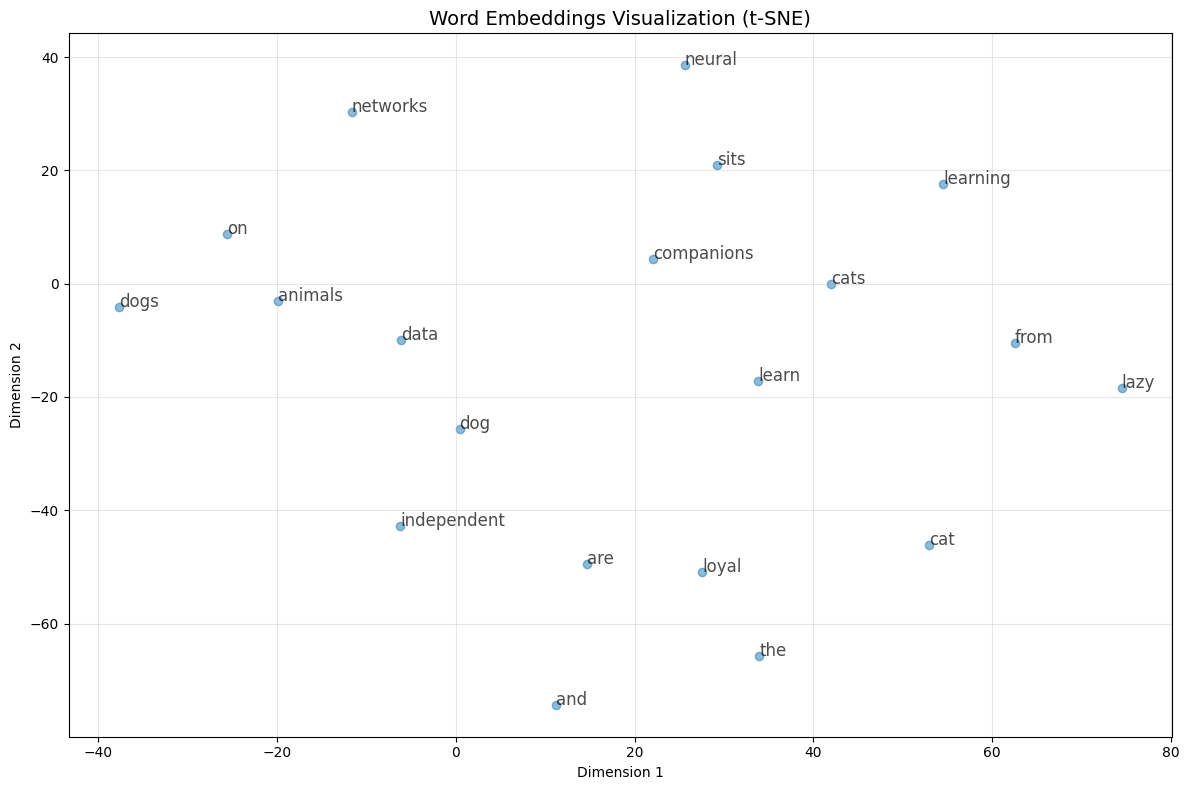


Interpretation:
  - Similar words appear closer together
  - Clusters show semantic relationships
  - t-SNE preserves local structure


In [13]:
# ----------------------------
# 13: Visualizing Word Embeddings with t-SNE
# ----------------------------
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Get word vectors
words = [word for word in skipgram_large.wv.index_to_key[:20]]
vectors = np.array([skipgram_large.wv[word] for word in words])

# Reduce to 2D using t-SNE
print("Reducing embeddings to 2D using t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(vectors)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5)

# Annotate points
for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                fontsize=12, alpha=0.7)

plt.title('Word Embeddings Visualization (t-SNE)', fontsize=14)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Similar words appear closer together")
print("  - Clusters show semantic relationships")
print("  - t-SNE preserves local structure")
# Output:

# Interpretation:
#   - Similar words appear closer together
#   - Clusters show semantic relationships
#   - t-SNE preserves local structure


In [14]:
# ----------------------------
# 14: Model Comparison - CBOW vs Skip-gram vs FastText
# ----------------------------

# Compare models on same task
test_word = 'cat'
print(f"Comparing models for word: '{test_word}'")
print("="*60)

models = {
    'CBOW': cbow_large,
    'Skip-gram': skipgram_large,
    'FastText': fasttext_model
}

for name, model in models.items():
    print(f"\n{name}:")
    if test_word in model.wv:
        # Get similar words
        similar = model.wv.most_similar(test_word, topn=5)
        print(f"  Most similar words:")
        for word, score in similar:
            print(f"    {word}: {score:.4f}")
        
        # Test specific similarities
        test_words = ['dog', 'animals', 'learning']
        print(f"  Similarity scores:")
        for tw in test_words:
            if tw in model.wv:
                sim = model.wv.similarity(test_word, tw)
                print(f"    {test_word} <-> {tw}: {sim:.4f}")

print("\n" + "="*60)
print("Observations:")
print("  - Different models capture different relationships")
print("  - Skip-gram often better for rare words")
print("  - CBOW faster to train")
print("  - FastText handles morphological variants")
# Output:
# Comparing models for word: 'cat'
# ============================================================

# CBOW:
#   Most similar words:
#     embeddings: 0.2523
#     lazy: 0.1705
#     loyal: 0.1503
#     jumps: 0.1493
#     text: 0.1477
#   Similarity scores:
#     cat <-> dog: -0.0708
#     cat <-> animals: -0.0072
#     cat <-> learning: -0.2037

# Skip-gram:
#   Most similar words:
#     embeddings: 0.2664
#     lazy: 0.1781
#     loyal: 0.1638
#     jumps: 0.1618
#     text: 0.1605
#   Similarity scores:
#     cat <-> dog: -0.0461
#     cat <-> animals: -0.0015
#     cat <-> learning: -0.2001

# FastText:
#   Most similar words:
#     cats: 0.3770
#     together: 0.3047
#     on: 0.2821
#     meaning: 0.2338
#     independent: 0.2012
#   Similarity scores:
#     cat <-> dog: -0.0433
#     cat <-> animals: 0.0652
#     cat <-> learning: 0.0230

# ============================================================
# Observations:
#   - Different models capture different relationships
#   - Skip-gram often better for rare words
#   - CBOW faster to train
#   - FastText handles morphological variants


Comparing models for word: 'cat'

CBOW:
  Most similar words:
    embeddings: 0.2523
    lazy: 0.1705
    loyal: 0.1503
    jumps: 0.1493
    text: 0.1477
  Similarity scores:
    cat <-> dog: -0.0708
    cat <-> animals: -0.0072
    cat <-> learning: -0.2037

Skip-gram:
  Most similar words:
    embeddings: 0.2664
    lazy: 0.1781
    loyal: 0.1638
    jumps: 0.1618
    text: 0.1605
  Similarity scores:
    cat <-> dog: -0.0461
    cat <-> animals: -0.0015
    cat <-> learning: -0.2001

FastText:
  Most similar words:
    cats: 0.3770
    together: 0.3047
    on: 0.2821
    meaning: 0.2338
    independent: 0.2012
  Similarity scores:
    cat <-> dog: -0.0433
    cat <-> animals: 0.0652
    cat <-> learning: 0.0230

Observations:
  - Different models capture different relationships
  - Skip-gram often better for rare words
  - CBOW faster to train
  - FastText handles morphological variants


In [15]:
# ----------------------------
# 15: Using Pre-trained Embeddings (Download Example)
# ----------------------------

# In practice, use pre-trained embeddings for better results
# Here's how to download and use them

print("Loading Pre-trained Word2Vec Embeddings:")
print("="*60)

# Example: Google's Word2Vec (would need to download)
# from gensim.models import KeyedVectors
# model = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin', binary=True)

print("\nPopular Pre-trained Embeddings:")
print("\n1. Word2Vec (Google):")
print("   - Trained on Google News corpus (~100B words)")
print("   - 300 dimensions")
print("   - 3M word vocabulary")
print("   - Download: https://code.google.com/archive/p/word2vec/")

print("\n2. GloVe (Stanford):")
print("   - Trained on Wikipedia + Gigaword")
print("   - Multiple sizes: 50, 100, 200, 300 dimensions")
print("   - 400K word vocabulary")
print("   - Download: https://nlp.stanford.edu/projects/glove/")

print("\n3. FastText (Facebook):")
print("   - Trained on Common Crawl + Wikipedia")
print("   - 300 dimensions")
print("   - Supports 157 languages")
print("   - Download: https://fasttext.cc/docs/en/crawl-vectors.html")

print("\nLoading example (if you have downloaded):")
print("""
# Word2Vec
from gensim.models import KeyedVectors
w2v = KeyedVectors.load_word2vec_format('path/to/GoogleNews-vectors-negative300.bin', binary=True)

# GloVe (convert to Word2Vec format first)
from gensim.scripts.glove2word2vec import glove2word2vec
glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.word2vec.txt')
glove = KeyedVectors.load_word2vec_format('glove.6B.100d.word2vec.txt')

# FastText
import fasttext
ft = fasttext.load_model('cc.en.300.bin')
""")

print("\n" + "="*60)
print("Advantages of pre-trained embeddings:")
print("  ✓ Trained on massive corpora")
print("  ✓ Better semantic representations")
print("  ✓ Transfer learning to your task")
print("  ✓ Save training time and resources")

Loading Pre-trained Word2Vec Embeddings:

Popular Pre-trained Embeddings:

1. Word2Vec (Google):
   - Trained on Google News corpus (~100B words)
   - 300 dimensions
   - 3M word vocabulary
   - Download: https://code.google.com/archive/p/word2vec/

2. GloVe (Stanford):
   - Trained on Wikipedia + Gigaword
   - Multiple sizes: 50, 100, 200, 300 dimensions
   - 400K word vocabulary
   - Download: https://nlp.stanford.edu/projects/glove/

3. FastText (Facebook):
   - Trained on Common Crawl + Wikipedia
   - 300 dimensions
   - Supports 157 languages
   - Download: https://fasttext.cc/docs/en/crawl-vectors.html

Loading example (if you have downloaded):

# Word2Vec
from gensim.models import KeyedVectors
w2v = KeyedVectors.load_word2vec_format('path/to/GoogleNews-vectors-negative300.bin', binary=True)

# GloVe (convert to Word2Vec format first)
from gensim.scripts.glove2word2vec import glove2word2vec
glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.word2vec.txt')
glove = KeyedVectors.loa

In [16]:
# ----------------------------
# 16: Practical Application - Document Classification
# ----------------------------

# Use word embeddings for document classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Sample documents with labels
documents = [
    "cats and dogs are pets",
    "the cat sleeps on the mat",
    "dogs are loyal animals",
    "machine learning is fascinating",
    "neural networks learn from data",
    "deep learning uses many layers",
    "natural language processing analyzes text",
    "the dog plays in the park",
    "embeddings capture semantic meaning",
    "animals need food and water"
]

labels = [
    'animals', 'animals', 'animals',
    'tech', 'tech', 'tech', 'tech',
    'animals', 'tech', 'animals'
]

# Convert documents to embeddings (average word vectors)
def document_to_vector(doc, model):
    """Convert document to vector by averaging word embeddings"""
    words = doc.split()
    word_vectors = []
    
    for word in words:
        if word in model.wv:
            word_vectors.append(model.wv[word])
    
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# Get document vectors
doc_vectors = np.array([document_to_vector(doc, skipgram_large) for doc in documents])

print("Document Classification using Word Embeddings:")
print("="*60)
print(f"Number of documents: {len(documents)}")
print(f"Document vector shape: {doc_vectors[0].shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    doc_vectors, labels, test_size=0.3, random_state=42
)

# Train classifier
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)

# Evaluate
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

print(f"\nTraining accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Test on new documents
new_docs = [
    "the cat and dog are friends",
    "deep neural networks for learning"
]

print("\nPredictions on new documents:")
for doc in new_docs:
    vec = document_to_vector(doc, skipgram_large).reshape(1, -1)
    pred = clf.predict(vec)[0]
    prob = clf.predict_proba(vec)[0]
    print(f"\nDocument: '{doc}'")
    print(f"  Predicted: {pred}")
    print(f"  Probabilities: animals={prob[0]:.4f}, tech={prob[1]:.4f}")

print("\n" + "="*60)
print("Key Idea: Word embeddings capture semantic meaning,")
print("allowing simple averaging to create document representations!")
# Output:
# Document Classification using Word Embeddings:
# ============================================================
# Number of documents: 10
# Document vector shape: (100,)

# Training accuracy: 0.5714
# Test accuracy: 0.3333

# Predictions on new documents:

# Document: 'the cat and dog are friends'
#   Predicted: animals
#   Probabilities: animals=0.5716, tech=0.4284

# Document: 'deep neural networks for learning'
#   Predicted: animals
#   Probabilities: animals=0.5712, tech=0.4288

# ============================================================
# Key Idea: Word embeddings capture semantic meaning,
# allowing simple averaging to create document representations!


Document Classification using Word Embeddings:
Number of documents: 10
Document vector shape: (100,)

Training accuracy: 0.5714
Test accuracy: 0.3333

Predictions on new documents:

Document: 'the cat and dog are friends'
  Predicted: animals
  Probabilities: animals=0.5716, tech=0.4284

Document: 'deep neural networks for learning'
  Predicted: animals
  Probabilities: animals=0.5712, tech=0.4288

Key Idea: Word embeddings capture semantic meaning,
allowing simple averaging to create document representations!


In [17]:
# ----------------------------
# 17: Summary and Comparison Table
# ----------------------------

import pandas as pd

# Create comparison table
comparison_data = {
    'Method': ['CBOW', 'Skip-gram', 'GloVe', 'FastText'],
    'Training': ['Predictive', 'Predictive', 'Count-based', 'Predictive'],
    'Direction': ['Context→Target', 'Target→Context', 'Co-occurrence', 'Target→Context'],
    'Speed': ['Fast', 'Moderate', 'Fast', 'Moderate'],
    'Rare Words': ['Poor', 'Better', 'Moderate', 'Excellent'],
    'OOV Handling': ['No', 'No', 'No', 'Yes'],
    'Morphology': ['No', 'No', 'No', 'Yes'],
    'Best For': ['Large corpus', 'Small corpus', 'General', 'Rich morphology']
}

df = pd.DataFrame(comparison_data)

print("Word Embedding Methods Comparison:")
print("="*80)
print(df.to_string(index=False))

print("\n" + "="*80)
print("Key Takeaways:")
print("="*80)

print("\n1. CBOW (Continuous Bag of Words):")
print("   ✓ Fast training")
print("   ✓ Good for frequent words")
print("   ✗ Poor on rare words")
print("   Use case: Large corpus with frequent vocabulary")

print("\n2. Skip-gram:")
print("   ✓ Better for rare words")
print("   ✓ Captures more context")
print("   ✗ Slower training")
print("   Use case: Smaller corpus, need rare word quality")

print("\n3. GloVe:")
print("   ✓ Uses global co-occurrence statistics")
print("   ✓ Fast training on large data")
print("   ✓ Linear vector relationships")
print("   Use case: General purpose, have large corpus")

print("\n4. FastText:")
print("   ✓ Character n-grams capture morphology")
print("   ✓ Handles out-of-vocabulary words")
print("   ✓ Excellent for rare words")
print("   ✗ Higher memory usage")
print("   Use case: Morphologically rich languages, need OOV handling")

print("\n" + "="*80)
print("Practical Recommendations:")
print("="*80)
print("• Start with pre-trained embeddings (Word2Vec, GloVe, FastText)")
print("• Use FastText if you need OOV handling")
print("• Fine-tune on your domain-specific corpus")
print("• Embedding dimension: 50-300 (more = more info, but slower)")
print("• Window size: 5-10 (smaller = syntax, larger = semantics)")
print("• For modern NLP: consider contextual embeddings (BERT, etc.)")
# Output:
# Word Embedding Methods Comparison:
# ================================================================================
#    Method    Training      Direction    Speed Rare Words OOV Handling Morphology        Best For
#      CBOW  Predictive Context→Target     Fast       Poor           No         No    Large corpus
# Skip-gram  Predictive Target→Context Moderate     Better           No         No    Small corpus
#     GloVe Count-based  Co-occurrence     Fast   Moderate           No         No         General
#  FastText  Predictive Target→Context Moderate  Excellent          Yes        Yes Rich morphology

# ================================================================================
# Key Takeaways:
# ================================================================================

# 1. CBOW (Continuous Bag of Words):
#    ✓ Fast training
#    ✓ Good for frequent words
#    ✗ Poor on rare words
#    Use case: Large corpus with frequent vocabulary

# 2. Skip-gram:
#    ✓ Better for rare words
#    ✓ Captures more context
#    ✗ Slower training
#    Use case: Smaller corpus, need rare word quality

# 3. GloVe:
# ...
# • Fine-tune on your domain-specific corpus
# • Embedding dimension: 50-300 (more = more info, but slower)
# • Window size: 5-10 (smaller = syntax, larger = semantics)
# • For modern NLP: consider contextual embeddings (BERT, etc.)


Word Embedding Methods Comparison:
   Method    Training      Direction    Speed Rare Words OOV Handling Morphology        Best For
     CBOW  Predictive Context→Target     Fast       Poor           No         No    Large corpus
Skip-gram  Predictive Target→Context Moderate     Better           No         No    Small corpus
    GloVe Count-based  Co-occurrence     Fast   Moderate           No         No         General
 FastText  Predictive Target→Context Moderate  Excellent          Yes        Yes Rich morphology

Key Takeaways:

1. CBOW (Continuous Bag of Words):
   ✓ Fast training
   ✓ Good for frequent words
   ✗ Poor on rare words
   Use case: Large corpus with frequent vocabulary

2. Skip-gram:
   ✓ Better for rare words
   ✓ Captures more context
   ✗ Slower training
   Use case: Smaller corpus, need rare word quality

3. GloVe:
   ✓ Uses global co-occurrence statistics
   ✓ Fast training on large data
   ✓ Linear vector relationships
   Use case: General purpose, have large cor